# Multi-Agent Quantitative Bipolar Argumentation
This notebook provides examples for multi-agent bipolar argumentation.

## Setup
Let us first install and import some dependencies.


In [ ]:
%%capture
!apt install libgraphviz-dev
!pip install pygraphviz
!pip install 'QBAF-Py[Visualizer] @ git+https://github.com/filipnaudot/Quantitative-Bipolar-Argumentation.git'

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from qbaf_visualizer.Visualizer import *
from qbaf_ctrbs.removal import *
from qbaf_ctrbs.intrinsic_removal import *
from qbaf_ctrbs.shapley import *
from qbaf_ctrbs.gradient import *

We introduce a helper function for plotting the final strength of one argument depending on the initial strength of another.

In [ ]:
def func(contributor_strength, contributor, qbaf, topic):
        initial_strengths = []
        argument_list = list(qbaf.arguments)
        for arg in argument_list:
            if arg == contributor:
                initial_strengths.append(contributor_strength)
            else:
                initial_strengths.append(qbaf.initial_strength(arg))
        qbaf_changed = QBAFramework(argument_list, initial_strengths,
                                    qbaf.attack_relations.relations,
                                    qbaf.support_relations.relations,
                                    semantics=qbaf.semantics)
        return qbaf_changed.final_strength(topic)

## Examples

### In Expansion-Reduction Dialogues Equilibria Cannot Be Guaranteed

#### DFQuAD Semantics

Contribution e to a, intrinsic removal: 0.0
Contribution e to a, gradient: -0.4999999925494194


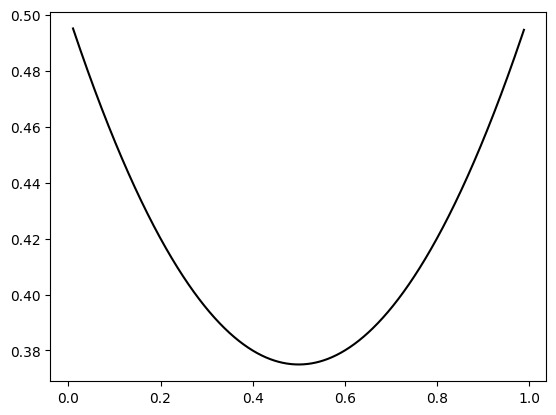

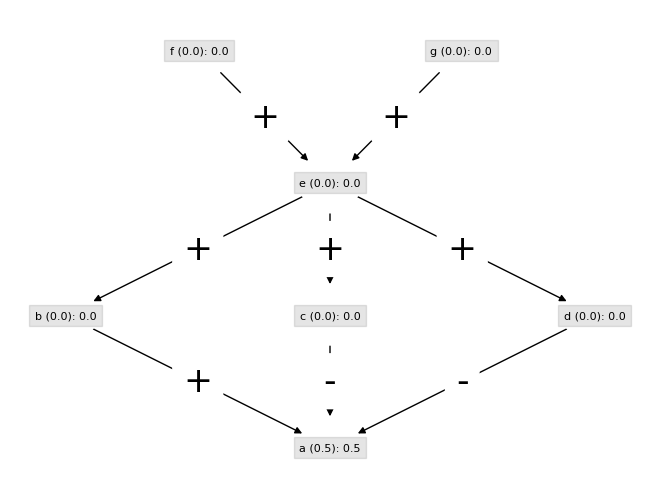

In [ ]:
args = ['a', 'b', 'c', 'd', 'e', 'f', 'g']
initial_strengths = [0.5, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
atts = [('c', 'a'), ('d', 'a')]
supps = [('b', 'a'), ('e', 'b'), ('e', 'c'), ('e', 'd'), ('f', 'e'), ('g', 'e')]
qbaf = QBAFramework(args, initial_strengths, atts, supps, semantics="DFQuAD_model")
ir_ctrb_e_to_a = determine_iremoval_ctrb('a', 'e', qbaf)
g_ctrb_e_to_a = determine_gradient_ctrb('a', 'e', qbaf)
print('Contribution e to a, intrinsic removal:', ir_ctrb_e_to_a)
print('Contribution e to a, gradient:', g_ctrb_e_to_a)


def plot_example():
    ises = []
    fsas = []
    for ise in range(10, 990):
        fise = ise / 1000
        ises.append(fise)
        fsas.append(abs(func(fise, 'f', qbaf, 'a')))
    plt.plot(np.array(ises), np.array(fsas), color='black')
    plt.show()
plot_example()
visualize(qbaf, with_fs=True, round_to=6)

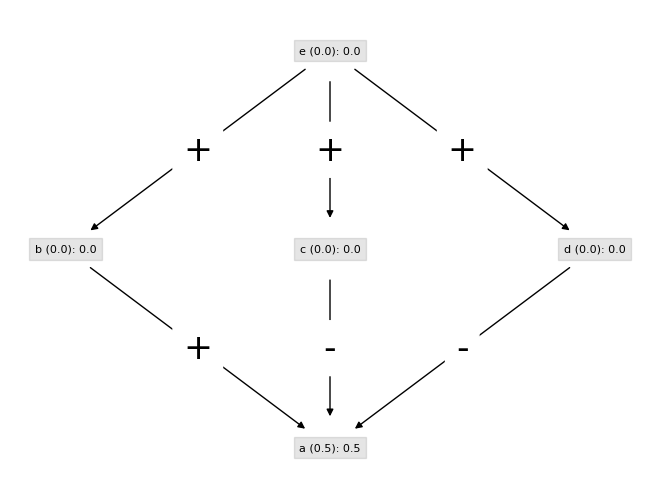

In [ ]:
args = ['a', 'b', 'c', 'd', 'e']
initial_strengths = [0.5, 0.0, 0.0, 0.0, 0.0]
atts = [('c', 'a'), ('d', 'a')]
supps = [('b', 'a'), ('e', 'b'), ('e', 'c'), ('e', 'd')]
qbaf = QBAFramework(args, initial_strengths, atts, supps, semantics="DFQuAD_model")
visualize(qbaf, with_fs=True, round_to=6)

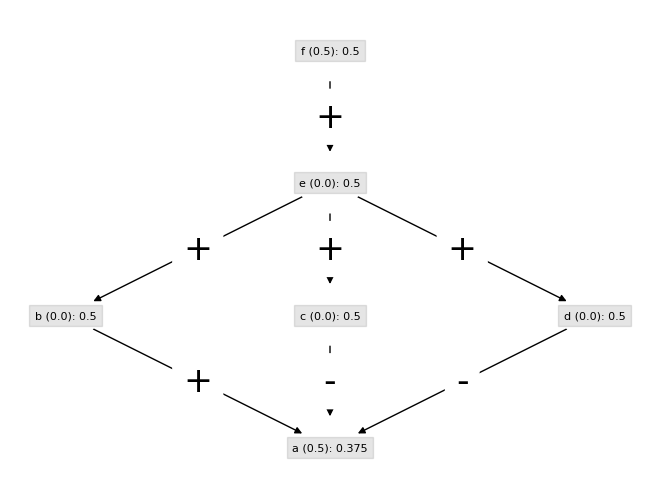

In [ ]:
args = ['a', 'b', 'c', 'd', 'e', 'f']
initial_strengths = [0.5, 0.0, 0.0, 0.0, 0.0, 0.5]
atts = [('c', 'a'), ('d', 'a')]
supps = [('b', 'a'), ('e', 'b'), ('e', 'c'), ('e', 'd'), ('f', 'e')]
qbaf = QBAFramework(args, initial_strengths, atts, supps, semantics="DFQuAD_model")
visualize(qbaf, with_fs=True, round_to=6)

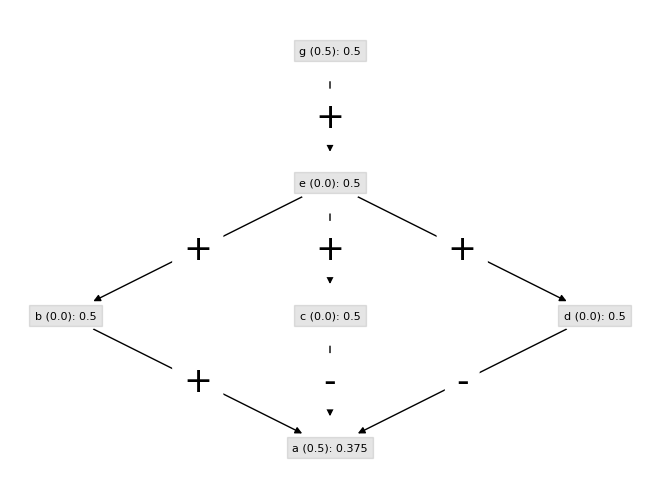

In [ ]:
args = ['a', 'b', 'c', 'd', 'e', 'g']
initial_strengths = [0.5, 0.0, 0.0, 0.0, 0.0, 0.5]
atts = [('c', 'a'), ('d', 'a')]
supps = [('b', 'a'), ('e', 'b'), ('e', 'c'), ('e', 'd'), ('g', 'e')]
qbaf = QBAFramework(args, initial_strengths, atts, supps, semantics="DFQuAD_model")
visualize(qbaf, with_fs=True, round_to=6)

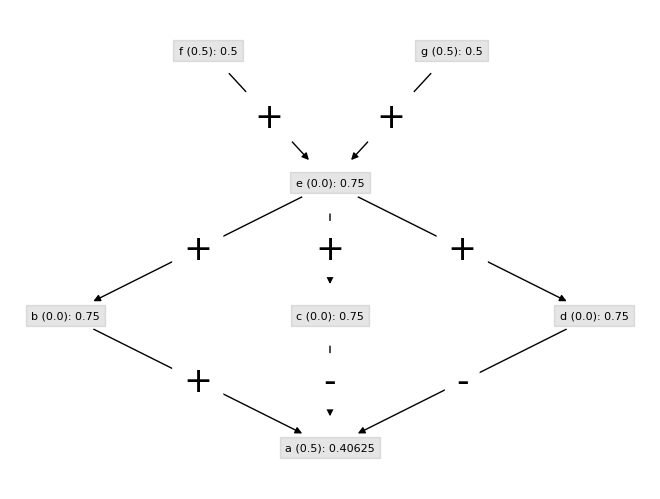

In [ ]:
args = ['a', 'b', 'c', 'd', 'e', 'f', 'g']
initial_strengths = [0.5, 0.0, 0.0, 0.0, 0.0, 0.5, 0.5]
atts = [('c', 'a'), ('d', 'a')]
supps = [('b', 'a'), ('e', 'b'), ('e', 'c'), ('e', 'd'), ('f', 'e'), ('g', 'e')]
qbaf = QBAFramework(args, initial_strengths, atts, supps, semantics="DFQuAD_model")
visualize(qbaf, with_fs=True, round_to=6)

In [ ]:
def get_qbaf_no_fg():
  args = ['a', 'b', 'c', 'd', 'e']
  initial_strengths = [0.5, 0.0, 0.0, 0.0, 0.0]
  atts = [('c', 'a'), ('d', 'a')]
  supps = [('b', 'a'), ('e', 'b'), ('e', 'c'), ('e', 'd')]
  return QBAFramework(args, initial_strengths, atts, supps, semantics="DFQuAD_model")

def get_qbaf_f():
  args = ['a', 'b', 'c', 'd', 'e', 'f']
  initial_strengths = [0.5, 0.0, 0.0, 0.0, 0.0, 0.5]
  atts = [('c', 'a'), ('d', 'a')]
  supps = [('b', 'a'), ('e', 'b'), ('e', 'c'), ('e', 'd'), ('f', 'e')]
  return QBAFramework(args, initial_strengths, atts, supps, semantics="DFQuAD_model")

def get_qbaf_g():
  args = ['a', 'b', 'c', 'd', 'e', 'g']
  initial_strengths = [0.5, 0.0, 0.0, 0.0, 0.0, 0.5]
  atts = [('c', 'a'), ('d', 'a')]
  supps = [('b', 'a'), ('e', 'b'), ('e', 'c'), ('e', 'd'), ('g', 'e')]
  return QBAFramework(args, initial_strengths, atts, supps, semantics="DFQuAD_model")

def get_qbaf_fg():
  args = ['a', 'b', 'c', 'd', 'e', 'f', 'g']
  initial_strengths = [0.5, 0.0, 0.0, 0.0, 0.0, 0.5, 0.5]
  atts = [('c', 'a'), ('d', 'a')]
  supps = [('b', 'a'), ('e', 'b'), ('e', 'c'), ('e', 'd'), ('f', 'e'), ('g', 'e')]
  return QBAFramework(args, initial_strengths, atts, supps, semantics="DFQuAD_model")

print("1. We start with the QBAF qbaf_no_fg where both f and g are absent.")
qbaf_nofg = get_qbaf_no_fg()
print("Agent A can either 'utter f' by adding it to the QBAF (yielding qbaf_f), or do nothing.")
print("A's objective is to minimze the final strength of a.")
qbaf_f = get_qbaf_f()
print("Contribution of f to a in qbaf_f: ", determine_removal_ctrb('a', 'f', qbaf_f))
print("2. As f's contibution to a is negative, A utters f.")
print("Now, Agent B can either 'utter g' by adding it to the QBAF (yielding qbaf_fg), or do nothing.")
print("B's objective is to maximize the final strength of a.")
qbaf_fg = get_qbaf_fg()
print("Contribution of g to a in qbaf_fg: ", determine_removal_ctrb('a', 'g', qbaf_fg))
print("As g's contibution to a is positive, B utters g.")
print("Next, A can 'withdraw f' by removing it from the QBAF (yielding qbaf_g), or do nothing.")
print("Contribution of f to a in qbaf_fg: ", determine_removal_ctrb('a', 'f', qbaf_fg))
print("3. As f's contibution to a is now positive, A withdraws f.")
print("Now, Agent B can either 'withdraw g' by removing it from the QBAF (yielding qbaf_no_fg), or do nothing.")
qbaf_g = get_qbaf_g()
print("Contribution of g to a in qbaf_g: ", determine_removal_ctrb('a', 'g', qbaf_g))
print("4. As g's contibution to a is now negative, B withdraws g.")
print("This means we are back at 1, it is an endless loop.")


1. We start with the QBAF qbaf_no_fg where both f and g are absent.
Agent A can either 'utter f' by adding it to the QBAF (yielding qbaf_f), or do nothing.
A's objective is to minimze the final strength of a.
Contribution of f to a in qbaf_f:  -0.125
2. As f's contibution to a is negative, A utters f.
Now, Agent B can either 'utter g' by adding it to the QBAF (yielding qbaf_fg), or do nothing.
B's objective is to maximize the final strength of a.
Contribution of g to a in qbaf_fg:  0.03125
As g's contibution to a is positive, B utters g.
Next, A can 'withdraw f' by removing it from the QBAF (yielding qbaf_g), or do nothing.
Contribution of f to a in qbaf_fg:  0.03125
3. As f's contibution to a is now positive, A withdraws f.
Now, Agent B can either 'withdraw g' by removing it from the QBAF (yielding qbaf_no_fg), or do nothing.
Contribution of g to a in qbaf_g:  -0.125
4. As g's contibution to a is now negative, B withdraws g.
This means we are back at 1, it is an endless loop.


#### QE Semantics

Contribution d to a, removal: -0.01122225976433966
Contribution d to a, gradient: 0.029868774116039276


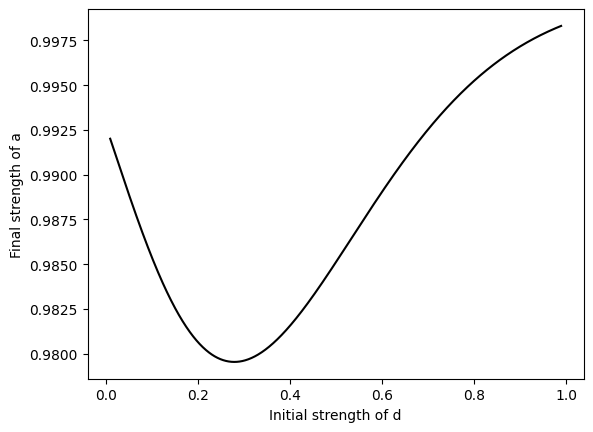

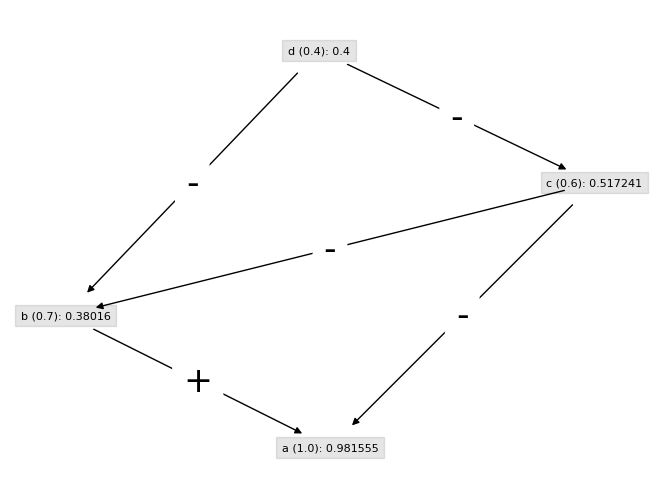

In [ ]:
args = ['a', 'b', 'c', 'd']
initial_strengths = [1, 0.7, 0.6, 0.4]
atts = [('c', 'b'), ('c', 'a'), ('d', 'b'),  ('d', 'c')]
supps = [('b', 'a')]
qbaf = QBAFramework(args, initial_strengths, atts, supps, semantics="QuadraticEnergy_model")
r_ctrb_d_to_a = determine_removal_ctrb('a', 'd', qbaf)
g_ctrb_d_to_a = determine_gradient_ctrb('a', 'd', qbaf)
print('Contribution d to a, removal:', r_ctrb_d_to_a)
print('Contribution d to a, gradient:', g_ctrb_d_to_a)


def plot_example():
    ises = []
    fsas = []
    for ise in range(10, 990):
        fise = ise / 1000
        ises.append(fise)
        fsas.append(abs(func(fise, 'd', qbaf, 'a')))
    plt.plot(np.array(ises), np.array(fsas), color='black')
    plt.xlabel('Initial strength of d')
    plt.ylabel('Final strength of a')
    plt.savefig('removal_qe.pdf')
    plt.show()
plot_example()
visualize(qbaf, with_fs=True, round_to=6)

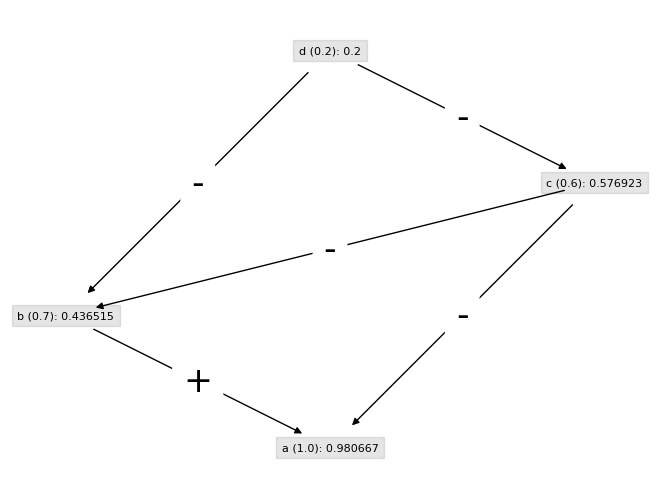

In [ ]:
args = ['a', 'b', 'c', 'd']
initial_strengths = [1, 0.7, 0.6, 0.2]
atts = [('c', 'b'), ('c', 'a'), ('d', 'b'),  ('d', 'c')]
supps = [('b', 'a')]
qbaf = QBAFramework(args, initial_strengths, atts, supps, semantics="QuadraticEnergy_model")
visualize(qbaf, with_fs=True, round_to=6)

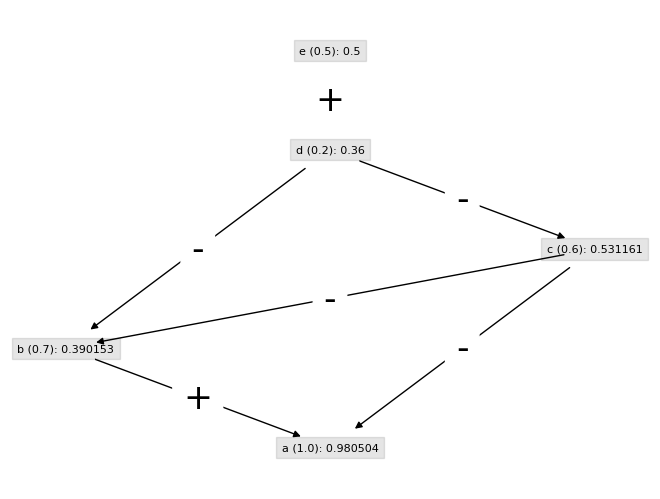

In [ ]:
args = ['a', 'b', 'c', 'd', 'e']
initial_strengths = [1, 0.7, 0.6, 0.2, 0.5]
atts = [('c', 'b'), ('c', 'a'), ('d', 'b'),  ('d', 'c')]
supps = [('b', 'a'), ('e', 'd')]
qbaf = QBAFramework(args, initial_strengths, atts, supps, semantics="QuadraticEnergy_model")
visualize(qbaf, with_fs=True, round_to=6)

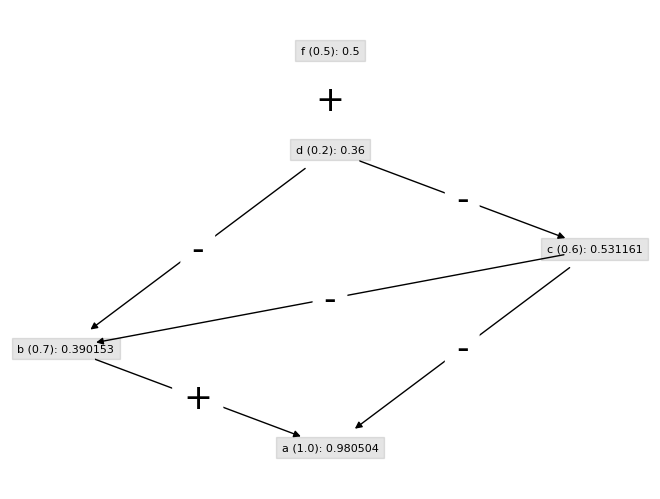

In [ ]:
args = ['a', 'b', 'c', 'd', 'f']
initial_strengths = [1, 0.7, 0.6, 0.2, 0.5]
atts = [('c', 'b'), ('c', 'a'), ('d', 'b'),  ('d', 'c')]
supps = [('b', 'a'), ('f', 'd')]
qbaf = QBAFramework(args, initial_strengths, atts, supps, semantics="QuadraticEnergy_model")
visualize(qbaf, with_fs=True, round_to=6)

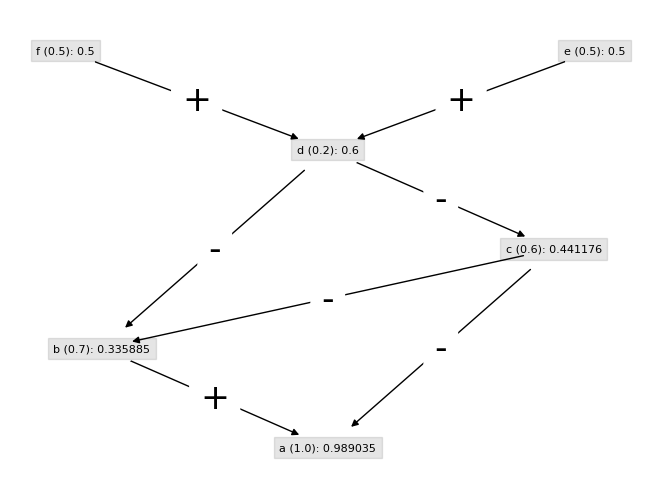

In [ ]:
args = ['a', 'b', 'c', 'd', 'e', 'f']
initial_strengths = [1, 0.7, 0.6, 0.2, 0.5, 0.5]
atts = [('c', 'b'), ('c', 'a'), ('d', 'b'),  ('d', 'c')]
supps = [('b', 'a'), ('e', 'd'), ('f', 'd')]
qbaf = QBAFramework(args, initial_strengths, atts, supps, semantics="QuadraticEnergy_model")
visualize(qbaf, with_fs=True, round_to=6)

In [ ]:
def get_qbaf_no_ef():
  args = ['a', 'b', 'c', 'd']
  initial_strengths = [1, 0.7, 0.6, 0.2]
  atts = [('c', 'b'), ('c', 'a'), ('d', 'b'),  ('d', 'c')]
  supps = [('b', 'a')]
  return QBAFramework(args, initial_strengths, atts, supps, semantics="QuadraticEnergy_model")

def get_qbaf_e():
  args = ['a', 'b', 'c', 'd', 'e']
  initial_strengths = [1, 0.7, 0.6, 0.2, 0.5]
  atts = [('c', 'b'), ('c', 'a'), ('d', 'b'),  ('d', 'c')]
  supps = [('b', 'a'), ('e', 'd')]
  return QBAFramework(args, initial_strengths, atts, supps, semantics="QuadraticEnergy_model")

def get_qbaf_f():
  args = ['a', 'b', 'c', 'd', 'f']
  initial_strengths = [1, 0.7, 0.6, 0.2, 0.5]
  atts = [('c', 'b'), ('c', 'a'), ('d', 'b'),  ('d', 'c')]
  supps = [('b', 'a'), ('f', 'd')]
  return QBAFramework(args, initial_strengths, atts, supps, semantics="QuadraticEnergy_model")

def get_qbaf_ef():
  args = ['a', 'b', 'c', 'd', 'e', 'f']
  initial_strengths = [1, 0.7, 0.6, 0.2, 0.5, 0.5]
  atts = [('c', 'b'), ('c', 'a'), ('d', 'b'),  ('d', 'c')]
  supps = [('b', 'a'), ('e', 'd'), ('f', 'd')]
  return QBAFramework(args, initial_strengths, atts, supps, semantics="QuadraticEnergy_model")

print("1. We start with the QBAF qbaf_no_ef where both e and f are absent.")
qbaf_noef = get_qbaf_no_ef()
print("Agent A can either 'utter e' by adding it to the QBAF (yielding qbaf_e), or do nothing.")
print("A's objective is to minimze the final strength of a.")
qbaf_e = get_qbaf_e()
print("Contribution of e to a in qbaf_e: ", determine_removal_ctrb('a', 'e', qbaf_e))
print("2. As e's contibution to a is negative, A utters e.")
print("Now, Agent B can either 'utter f' by adding it to the QBAF (yielding qbaf_ef), or do nothing.")
print("B's objective is to maximize the final strength of a.")
qbaf_ef = get_qbaf_ef()
print("Contribution of f to a in qbaf_ef: ", determine_removal_ctrb('a', 'f', qbaf_ef))
print("As f's contibution to a is positive, B utters f.")
print("Next, A can 'withdraw e' by removing it from the QBAF (yielding qbaf_f), or do nothing.")
print("Contribution of e to a in qbaf_ef: ", determine_removal_ctrb('a', 'e', qbaf_ef))
print("3. As e's contibution to a is now positive, A withdraws e.")
print("Now, Agent B can either 'withdraw f' by removing it from the QBAF (yielding qbaf_no_ef), or do nothing.")
qbaf_f = get_qbaf_f()
print("Contribution of f to a in qbaf_f: ", determine_removal_ctrb('a', 'f', qbaf_f))
print("4. As f's contibution to a is now negative, B withdraws f.")
print("This means we are back at 1, it is an endless loop.")

1. We start with the QBAF qbaf_no_ef where both e and f are absent.
Agent A can either 'utter e' by adding it to the QBAF (yielding qbaf_e), or do nothing.
A's objective is to minimze the final strength of a.
Contribution of e to a in qbaf_e:  -0.00016258374972299983
2. As e's contibution to a is negative, A utters e.
Now, Agent B can either 'utter f' by adding it to the QBAF (yielding qbaf_ef), or do nothing.
B's objective is to maximize the final strength of a.
Contribution of f to a in qbaf_ef:  0.008531001667340443
As f's contibution to a is positive, B utters f.
Next, A can 'withdraw e' by removing it from the QBAF (yielding qbaf_f), or do nothing.
Contribution of e to a in qbaf_ef:  0.008531001667340443
3. As e's contibution to a is now positive, A withdraws e.
Now, Agent B can either 'withdraw f' by removing it from the QBAF (yielding qbaf_no_ef), or do nothing.
Contribution of f to a in qbaf_f:  -0.00016258374972299983
4. As f's contibution to a is now negative, B withdraws f.


1) Start with G0 where utt(Ag1)=∅ and utt(Ag2)=∅.
G0 = ⟨{a}, ∅, ∅, {(a,0.5)}⟩ under DF-QuAD.
Ag2 considers uttering b.
Removal contribution of b to a in G1: 0.25
Ag2 moves to G1 = G_{ {b} } since b supports a (non-negative effect).

2) With G1 and utt(Ag1)=∅, utt(Ag2)={b}, Ag1 considers uttering c.
Removal contribution of c to a in G2: -0.25
Ag1 moves to G2 = G_{ {b,c} } since c attacks a (non-positive effect).

3) With G2 and utt(Ag1)={c}, utt(Ag2)={b}, Ag2 considers uttering e.
Removal contribution of e to a in G3: 0.125
Ag2 moves to G3 = G_{ {b,e,c} } since e supports a (non-negative effect).

4) With G3 and utt(Ag1)={c}, utt(Ag2)={b,e}, Ag1 considers uttering d.
Removal contribution of d to a in G4: -0.125
Ag1 moves to G4 = G_{ {b,e,c,d} } since d attacks a (non-positive effect).

5) In G4 we have utt(Ag1)={c,d} and utt(Ag2)={b,e}. Under DF-QuAD and clear polarity:
- Removing any attacker (c or d) or adding any supporter (b or e) strictly increases the strength of a.
- Removing any

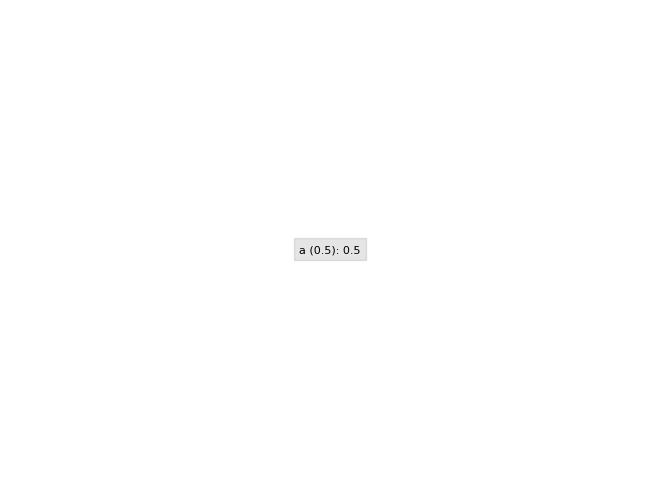

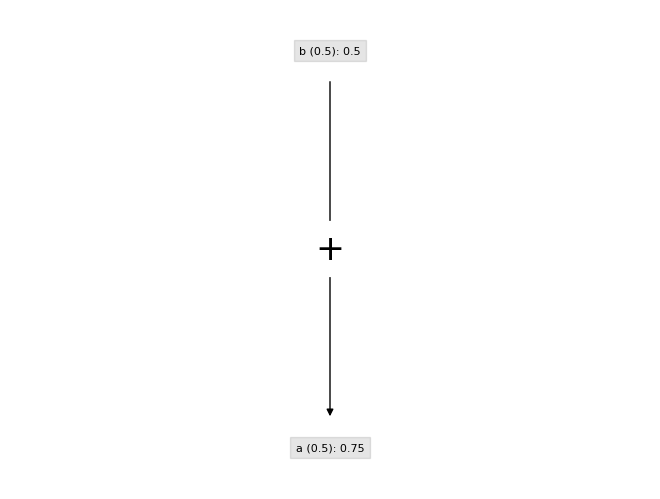

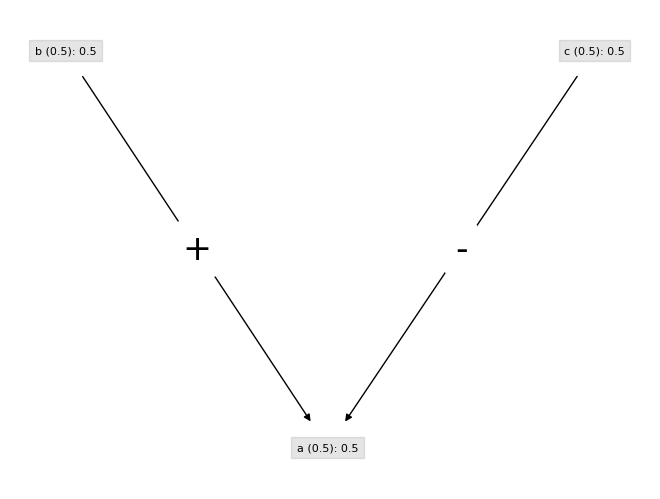

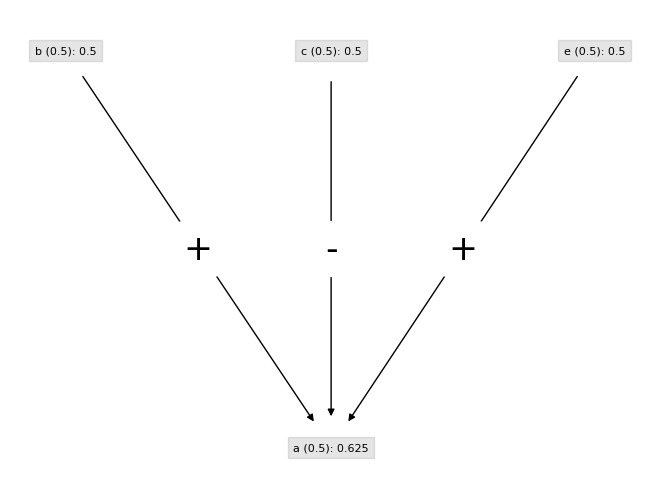

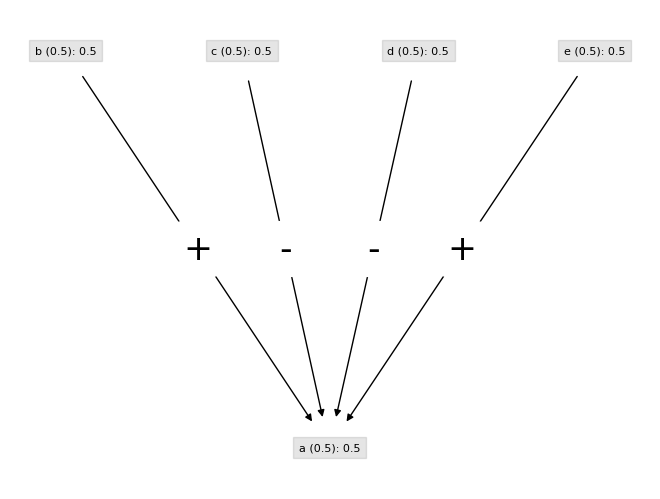

In [ ]:
def get_G0():
    args = ['a']
    initial_strengths = [0.5]  # uttered: {a}
    atts = []
    supps = []
    return QBAFramework(args, initial_strengths, atts, supps, semantics="DFQuAD_model")


def get_G1():
    args = ['a', 'b']
    initial_strengths = [0.5, 0.5]  # uttered: {a, b}
    atts = []
    supps = [('b', 'a')]
    return QBAFramework(args, initial_strengths, atts, supps, semantics="DFQuAD_model")


def get_G2():
    args = ['a', 'b', 'c']
    initial_strengths = [0.5, 0.5, 0.5]  # uttered: {a, b, c}
    atts = [('c', 'a')]
    supps = [('b', 'a')]
    return QBAFramework(args, initial_strengths, atts, supps, semantics="DFQuAD_model")


def get_G3():
    args = ['a', 'b', 'c', 'e']
    initial_strengths = [0.5, 0.5, 0.5, 0.5]  # uttered: {a, b, c, e}
    atts = [('c', 'a')]
    supps = [('b', 'a'), ('e', 'a')]
    return QBAFramework(args, initial_strengths, atts, supps, semantics="DFQuAD_model")


def get_G4():
    args = ['a', 'b', 'c', 'd', 'e']
    initial_strengths = [0.5, 0.5, 0.5, 0.5, 0.5]  # uttered: {a, b, c, d, e}
    atts = [('c', 'a'), ('d', 'a')]
    supps = [('b', 'a'), ('e', 'a')]
    return QBAFramework(args, initial_strengths, atts, supps, semantics="DFQuAD_model")





# --- Simulation of the utterance sequence ---
print("1) Start with G0 where utt(Ag1)=∅ and utt(Ag2)=∅.")
G0 = get_G0()
print("G0 = ⟨{a}, ∅, ∅, {(a,0.5)}⟩ under DF-QuAD.")
print("Ag2 considers uttering b.")

G1 = get_G1()
print("Removal contribution of b to a in G1:", determine_removal_ctrb('a', 'b', G1))
print("Ag2 moves to G1 = G_{ {b} } since b supports a (non-negative effect).")

print("\n2) With G1 and utt(Ag1)=∅, utt(Ag2)={b}, Ag1 considers uttering c.")
G2 = get_G2()
print("Removal contribution of c to a in G2:", determine_removal_ctrb('a', 'c', G2))
print("Ag1 moves to G2 = G_{ {b,c} } since c attacks a (non-positive effect).")

print("\n3) With G2 and utt(Ag1)={c}, utt(Ag2)={b}, Ag2 considers uttering e.")
G3 = get_G3()
print("Removal contribution of e to a in G3:", determine_removal_ctrb('a', 'e', G3))
print("Ag2 moves to G3 = G_{ {b,e,c} } since e supports a (non-negative effect).")

print("\n4) With G3 and utt(Ag1)={c}, utt(Ag2)={b,e}, Ag1 considers uttering d.")
G4 = get_G4()
print("Removal contribution of d to a in G4:", determine_removal_ctrb('a', 'd', G4))
print("Ag1 moves to G4 = G_{ {b,e,c,d} } since d attacks a (non-positive effect).")

print("\n5) In G4 we have utt(Ag1)={c,d} and utt(Ag2)={b,e}. Under DF-QuAD and clear polarity:")
print("- Removing any attacker (c or d) or adding any supporter (b or e) strictly increases the strength of a.")
print("- Removing any supporter or adding an attacker strictly decreases the strength of a.")
print("No profitable unilateral deviation exists. G4 is an utterance equilibrium.")

visualize(G0, with_fs=True, round_to=6)
plt.show()

visualize(G1, with_fs=True, round_to=6)
plt.show()

visualize(G2, with_fs=True, round_to=6)
plt.show()

visualize(G3, with_fs=True, round_to=6)
plt.show()

visualize(G4, with_fs=True, round_to=6)
plt.show()


### In Infinite Expansion Dialogues Equilibria Cannot Be Guaranteed

#### DFQuAD Semantics



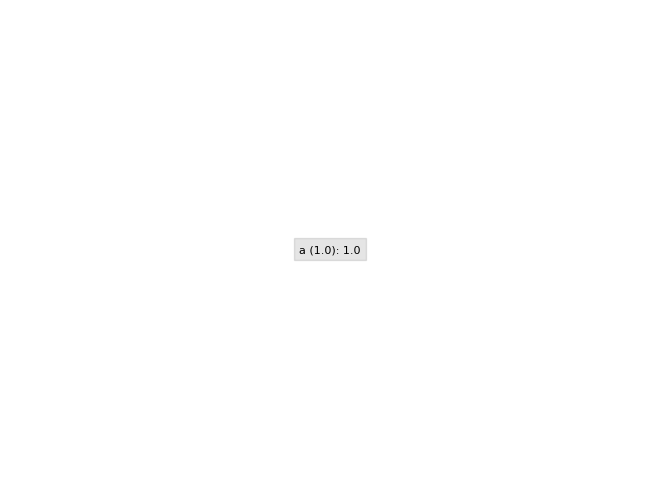

In [ ]:
args = ['a']
initial_strengths = [1]
atts = []
supps = []
qbaf = QBAFramework(args, initial_strengths, atts, supps, semantics="DFQuAD_model")
visualize(qbaf, with_fs=True, round_to=6)

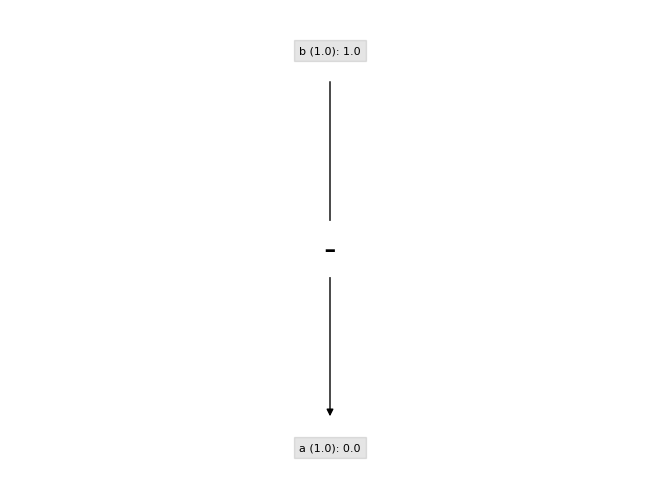

In [ ]:
args = ['a', 'b']
initial_strengths = [1, 1]
atts = [('b', 'a')]
supps = []
qbaf = QBAFramework(args, initial_strengths, atts, supps, semantics="DFQuAD_model")
visualize(qbaf, with_fs=True, round_to=6)

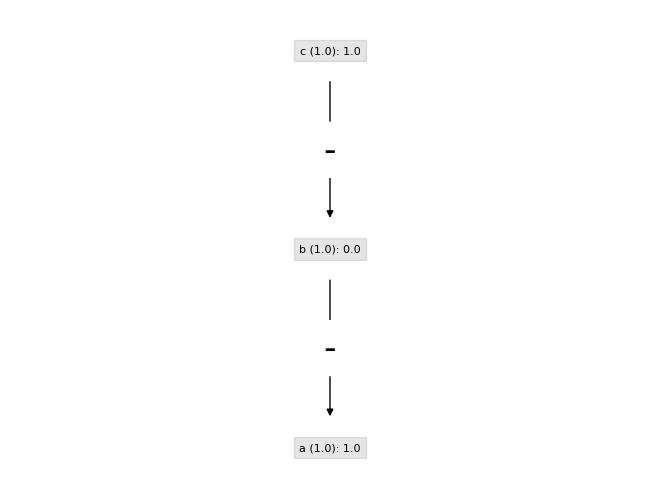

In [ ]:
args = ['a', 'b', 'c']
initial_strengths = [1, 1, 1]
atts = [('b', 'a'), ('c', 'b')]
qbaf = QBAFramework(args, initial_strengths, atts, supps, semantics="DFQuAD_model")
visualize(qbaf, with_fs=True, round_to=6)

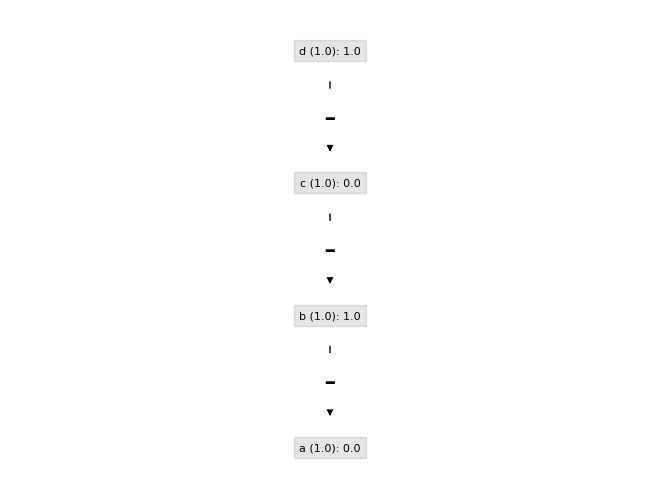

In [ ]:
args = ['a', 'b', 'c', 'd']
initial_strengths = [1, 1, 1, 1]
atts = [('b', 'a'), ('c', 'b'), ('d', 'c')]
qbaf = QBAFramework(args, initial_strengths, atts, supps, semantics="DFQuAD_model")
visualize(qbaf, with_fs=True, round_to=6)

#### QE Semantics

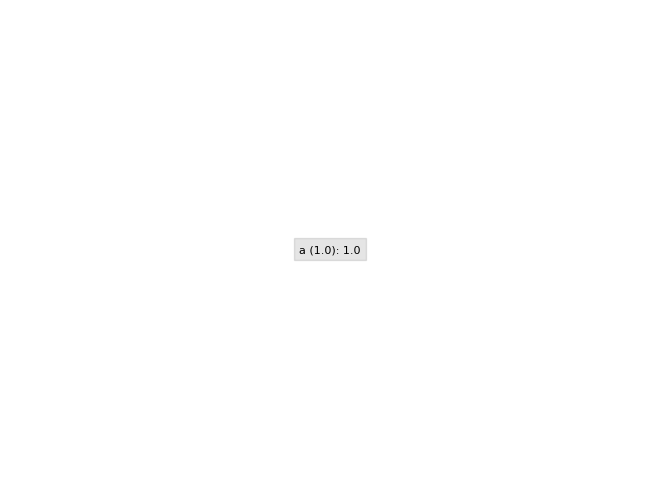

In [ ]:
args = ['a']
initial_strengths = [1]
atts = []
supps = []
qbaf = QBAFramework(args, initial_strengths, atts, supps, semantics="QuadraticEnergy_model")
visualize(qbaf, with_fs=True, round_to=6)

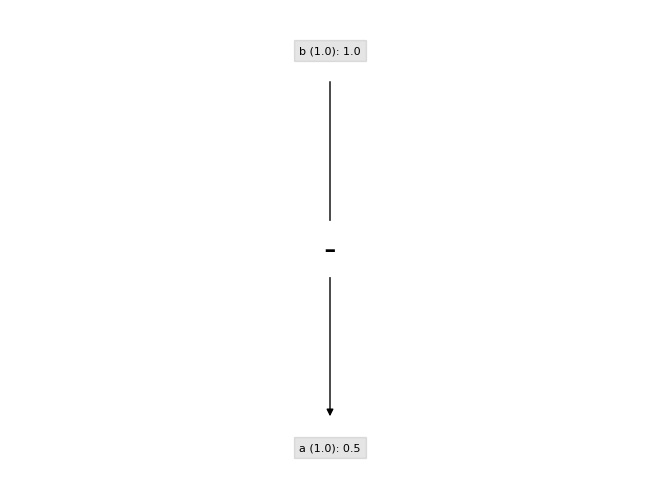

In [ ]:
args = ['a', 'b']
initial_strengths = [1, 1]
atts = [('b', 'a')]
supps = []
qbaf = QBAFramework(args, initial_strengths, atts, supps, semantics="QuadraticEnergy_model")
visualize(qbaf, with_fs=True, round_to=6)

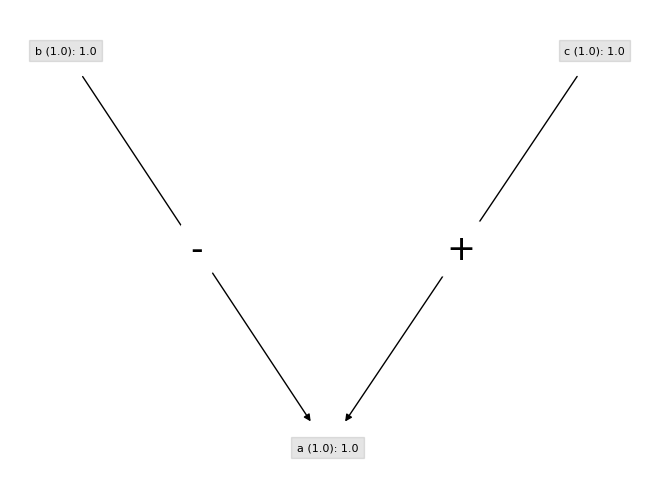

In [ ]:
args = ['a', 'b', 'c']
initial_strengths = [1, 1, 1]
atts = [('b', 'a')]
supps = [('c', 'a')]
qbaf = QBAFramework(args, initial_strengths, atts, supps, semantics="QuadraticEnergy_model")
visualize(qbaf, with_fs=True, round_to=6)

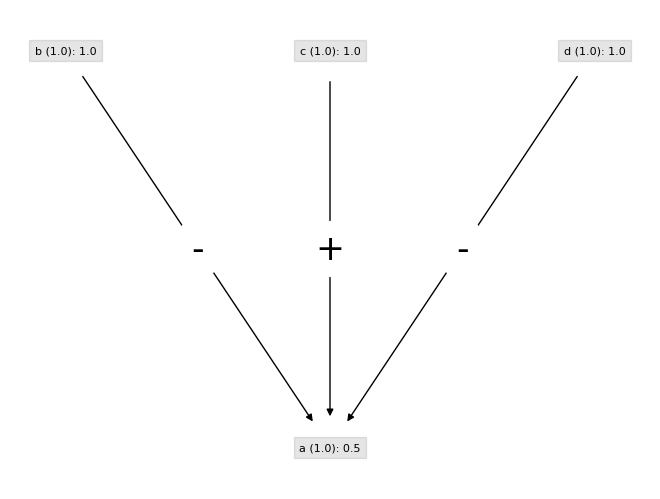

In [ ]:
args = ['a', 'b', 'c', 'd']
initial_strengths = [1, 1, 1, 1]
atts = [('b', 'a'), ('d', 'a')]
supps = [('c', 'a')]
qbaf = QBAFramework(args, initial_strengths, atts, supps, semantics="QuadraticEnergy_model")
visualize(qbaf, with_fs=True, round_to=6)

### Multi-Objective Issues in Expansion-Reduction Dialogues

#### DFQuAD Semantics

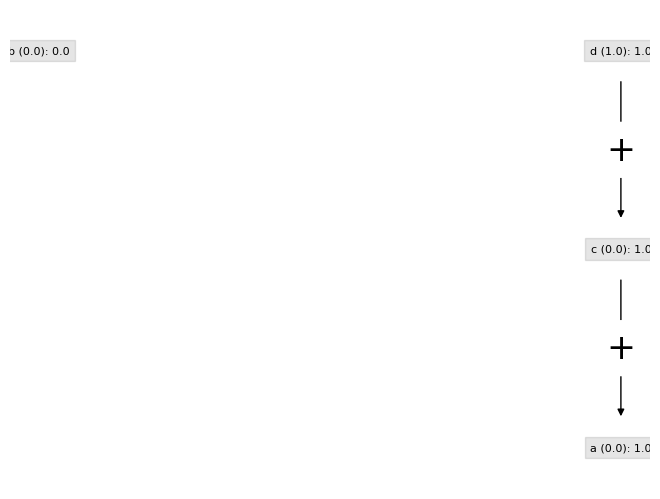

In [ ]:
args = ['a', 'b', 'c', 'd']
initial_strengths = [0, 0, 0, 1]
atts = []
supps = [('c', 'a'), ('d', 'c')]
qbaf = QBAFramework(args, initial_strengths, atts, supps, semantics="DFQuAD_model")
visualize(qbaf, with_fs=True, round_to=6)

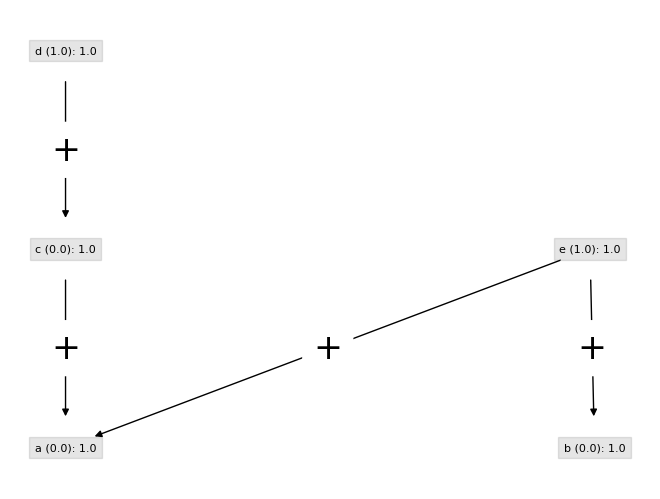

In [ ]:
args = ['a', 'b', 'c', 'd', 'e']
initial_strengths = [0, 0, 0, 1, 1]
atts = []
supps = [('c', 'a'), ('d', 'c'), ('e', 'a'), ('e', 'b')]
qbaf = QBAFramework(args, initial_strengths, atts, supps, semantics="DFQuAD_model")
visualize(qbaf, with_fs=True, round_to=6)

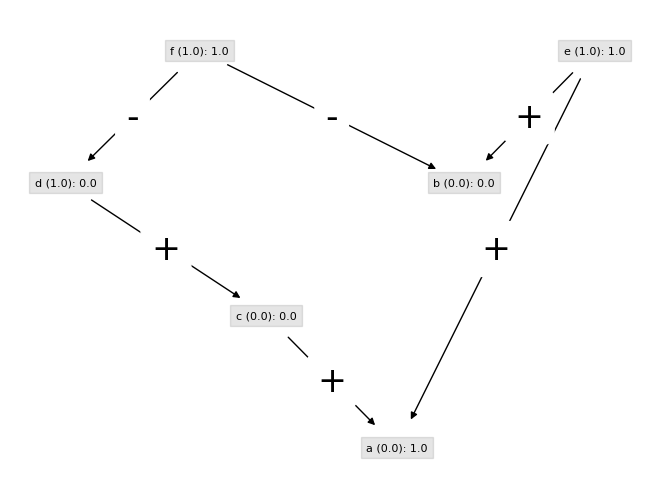

In [ ]:
args = ['a', 'b', 'c', 'd', 'e', 'f']
initial_strengths = [0, 0, 0, 1, 1, 1]
atts = [('f', 'd'), ('f', 'b')]
supps = [('c', 'a'), ('d', 'c'), ('e', 'a'), ('e', 'b')]
qbaf = QBAFramework(args, initial_strengths, atts, supps, semantics="DFQuAD_model")
visualize(qbaf, with_fs=True, round_to=6)

###

Exmaple: Preferences over Induced QBAFs

G1


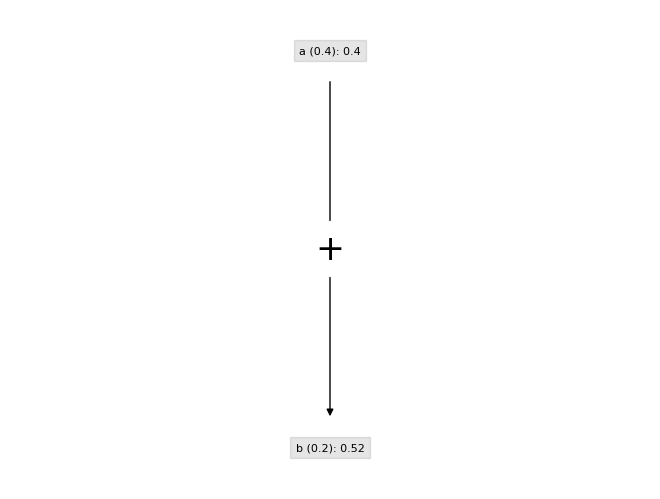

G2


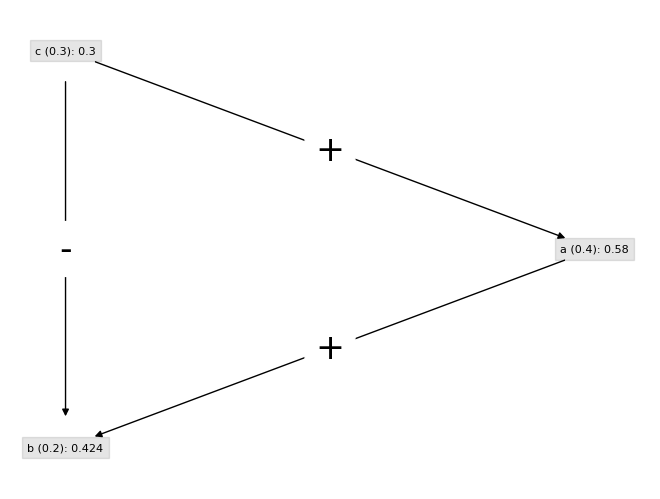

G3


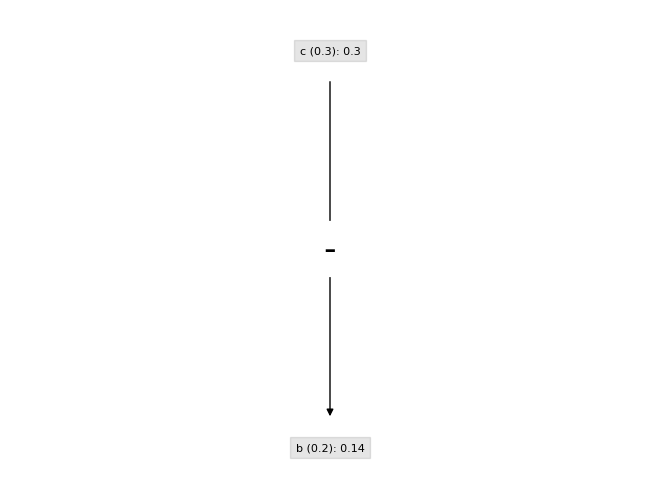

In [ ]:
# --- Example: preference over induced QBAFs G1 and G2 ---

def get_G1_example():
    args = ['a', 'b']
    initial_strengths = [0.4, 0.2]
    atts = []
    supps = [('a', 'b')]
    return QBAFramework(args, initial_strengths, atts, supps, semantics="DFQuAD_model")


def get_G2_example():
    args = ['a', 'b', 'c']
    initial_strengths = [0.4, 0.2, 0.3]
    atts = [('c', 'b')]
    supps = [('a', 'b'), ('c', 'a')]
    return QBAFramework(args, initial_strengths, atts, supps, semantics="DFQuAD_model")


def get_G3_example():
    args = ['b', 'c']
    initial_strengths = [0.2, 0.3]
    atts = [('c', 'b')]
    supps = []
    return QBAFramework(args, initial_strengths, atts, supps, semantics="DFQuAD_model")


# --- Build and visualize ---
G1_ex = get_G1_example()
G2_ex = get_G2_example()
G3_ex = get_G3_example()

print("G1")
visualize(G1_ex, with_fs=True, round_to=6)
plt.show()

print("G2")
visualize(G2_ex, with_fs=True, round_to=6)
plt.show()

print("G3")
visualize(G3_ex, with_fs=True, round_to=6)
plt.show()

Exmaple: Utterance ratonality

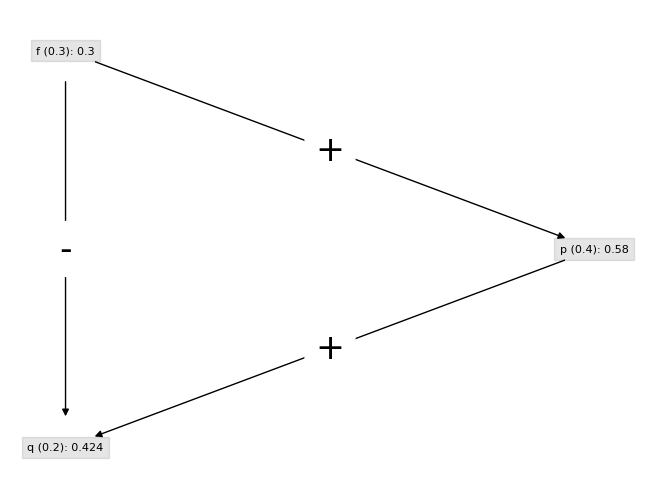

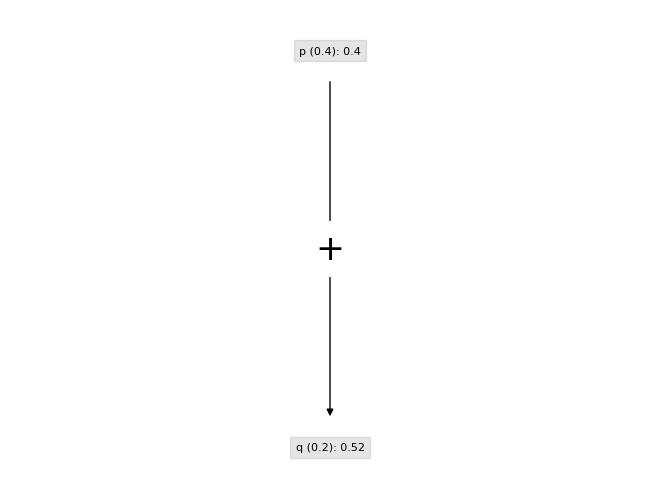

In [ ]:
# --- Exmaple: Utterance rationality ---

def get_G_utt():
    args = ['p', 'q', 'f']
    initial_strengths = [0.4, 0.2, 0.3]
    atts = [('f', 'q')]
    supps = [('p', 'q'), ('f', 'p')]
    return QBAFramework(args, initial_strengths, atts, supps, semantics="DFQuAD_model")


def get_G_utt_star():
    args = ['p', 'q']
    initial_strengths = [0.4, 0.2]
    atts = []
    supps = [('p', 'q')]
    return QBAFramework(args, initial_strengths, atts, supps, semantics="DFQuAD_model")


# --- Build and visualize ---
G_utt = get_G_utt()
visualize(G_utt, with_fs=True, round_to=6)
plt.show()

G_utt_star = get_G_utt_star()
visualize(G_utt_star, with_fs=True, round_to=6)
plt.show()


Example Utterance Equlibrium

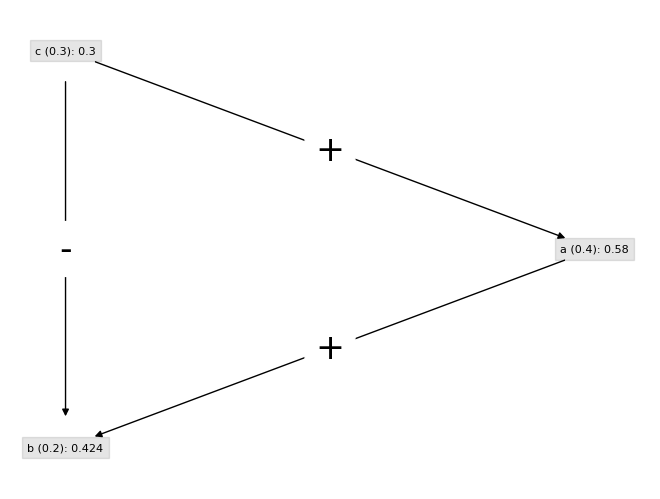

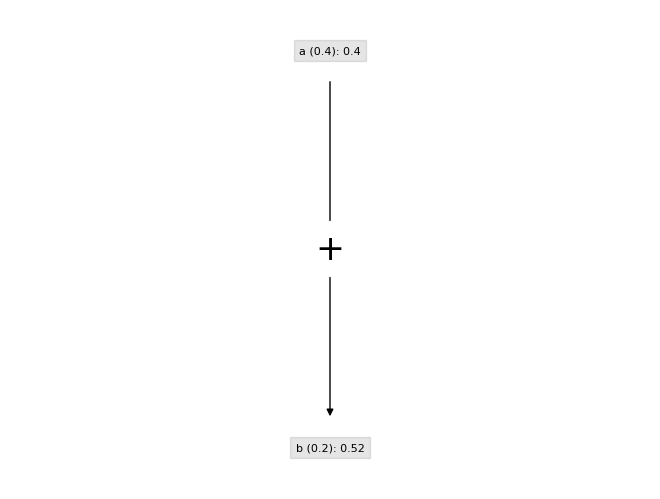

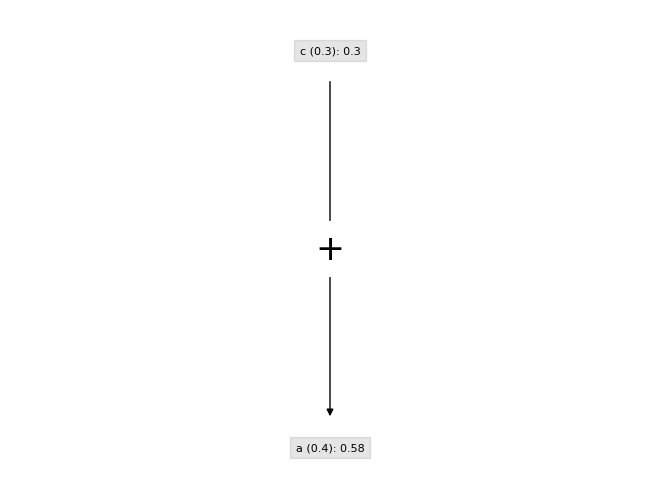

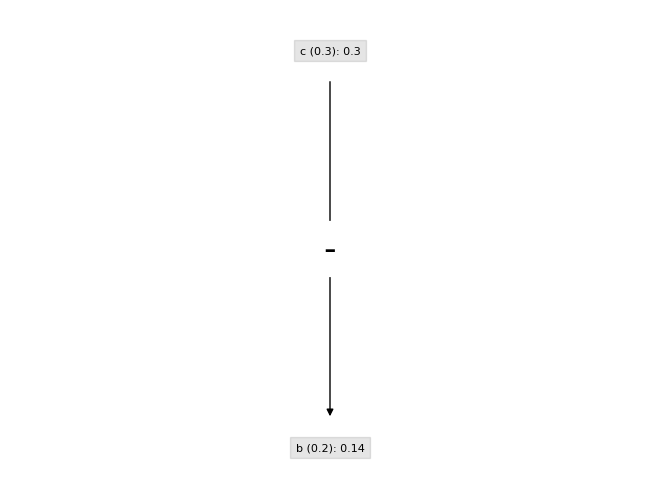

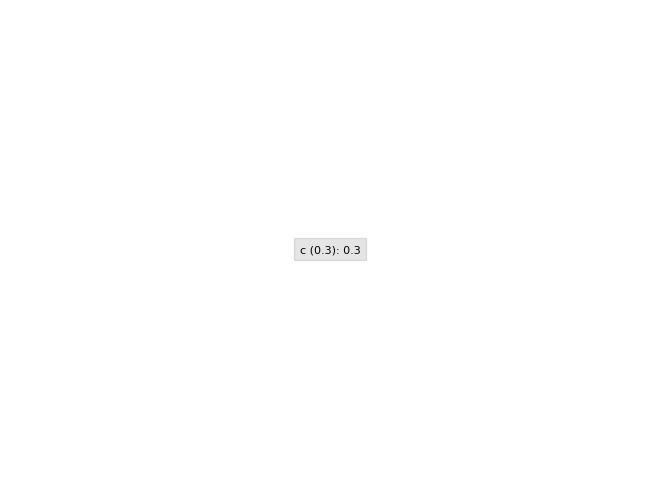

In [ ]:
# --- Example Utterance Equlibrium ---

def get_G_utt():
    args = ['a', 'b', 'c']
    initial_strengths = [0.4, 0.2, 0.3]
    atts = [('c', 'b')]
    supps = [('a', 'b'), ('c', 'a')]
    return QBAFramework(args, initial_strengths, atts, supps, semantics="DFQuAD_model")


def get_G_utt_star():
    args = ['a', 'b']
    initial_strengths = [0.4, 0.2]
    atts = []
    supps = [('a', 'b')]
    return QBAFramework(args, initial_strengths, atts, supps, semantics="DFQuAD_model")


# --- Ag2 deviation alternatives with utt(c)=Ag1 fixed ---

def get_G1_alt():
    args = ['a', 'c']
    initial_strengths = [0.4, 0.3]
    atts = []
    supps = [('c', 'a')]
    return QBAFramework(args, initial_strengths, atts, supps, semantics="DFQuAD_model")


def get_G2_alt():
    args = ['b', 'c']
    initial_strengths = [0.2, 0.3]
    atts = [('c', 'b')]
    supps = []
    return QBAFramework(args, initial_strengths, atts, supps, semantics="DFQuAD_model")


def get_G3_alt():
    args = ['c']
    initial_strengths = [0.3]
    atts = []
    supps = []
    return QBAFramework(args, initial_strengths, atts, supps, semantics="DFQuAD_model")


# --- Build and visualize ---

G_utt = get_G_utt()
G_utt_star = get_G_utt_star()
G1 = get_G1_alt()
G2 = get_G2_alt()
G3 = get_G3_alt()

# Visuals (comment out if not needed)
visualize(G_utt, with_fs=True, round_to=6); plt.show()
visualize(G_utt_star, with_fs=True, round_to=6); plt.show()
visualize(G1, with_fs=True, round_to=6); plt.show()
visualize(G2, with_fs=True, round_to=6); plt.show()
visualize(G3, with_fs=True, round_to=6); plt.show()

## MQBAF

In [ ]:
from typing import Dict, Set, Tuple, List
#from qbaf import QBAFramework

class MultiAgentQBAF:
    """
    Multi-Agent Quantitative Bipolar Argumentation Framework
    M = (<X, R-, R+, τ>, A, obj, pref)
    """

    def __init__(self, qbaf: QBAFramework,
                 agents: List[str],
                 obj: Dict[str, Set[Tuple[str, str]]],
                 pref: Dict[str, Set[Tuple[Tuple[str, str], Tuple[str, str]]]]):
        self.qbaf = qbaf
        self.A = set(agents)
        self.obj = obj
        self.pref = pref
        self._validate()

    # -----------------------------------------------------
    # Validation of MQBAF structural integrity
    # -----------------------------------------------------
    def _validate(self):
        X = set(self.qbaf.arguments)
        for ag in self.A:
            if ag not in self.obj:
                raise ValueError(f"Agent {ag} has no objectives.")
            if not self.obj[ag]:
                raise ValueError(f"Agent {ag} has empty objectives.")
            plus = {x for (x, d) in self.obj[ag] if d == '+'}
            minus = {x for (x, d) in self.obj[ag] if d == '-'}
            if plus & minus:
                raise ValueError(f"Agent {ag} has conflicting +/- objectives.")
            for (x, d) in self.obj[ag]:
                if x not in X:
                    raise ValueError(f"Objective ({x},{d}) not in QBAF.")
            for ((x, d), (y, d2)) in self.pref.get(ag, set()):
                if (x, d) not in self.obj[ag] or (y, d2) not in self.obj[ag]:
                    raise ValueError(f"Preference of {ag} references non-objective pairs.")

    def summary(self):
        """Print MQBAF structure for debugging."""
        print("=== Multi-Agent QBAF ===")
        print(f"Agents: {self.A}")
        print(f"Arguments (|X|={len(self.qbaf.arguments)}): {list(self.qbaf.arguments)}")
        for ag in self.A:
            print(f"\nAgent {ag}:")
            print(f"  Objectives: {self.obj[ag]}")
            print(f"  Preferences: {self.pref.get(ag, set())}")


    # -----------------------------------------------------
    # Utterance Profile
    # -----------------------------------------------------
    class UtteranceProfile:
        """
        Utterance profile utt^M : X ↦ A (partial function)
        utt(x) = Ag means argument x is uttered by agent Ag.
        """
        def __init__(self, M, mapping: Dict[str, str]):
            self.M = M
            self.mapping = mapping  # dict[arg -> agent]
            # Validate domain/range
            for x, ag in mapping.items():
                if x not in M.qbaf.arguments:
                    raise ValueError(f"UtteranceProfile: argument {x} not in QBAF.")
                if ag not in M.A:
                    raise ValueError(f"UtteranceProfile: agent {ag} not in A.")

        def uttered_arguments(self) -> Set[str]:
            """Return X' = {x ∈ X | ∃Ag: utt(x)=Ag}"""
            return set(self.mapping.keys())

        def __getitem__(self, arg):
            """Return the agent who uttered argument `arg` (if any)."""
            return self.mapping.get(arg, None)

        def __repr__(self):
            return f"UtteranceProfile({self.mapping})"

    # -----------------------------------------------------
    # Induced QBAF
    # -----------------------------------------------------
    def induced_qbaf(self, utt_profile: 'MultiAgentQBAF.UtteranceProfile') -> QBAFramework:
        """
        Construct the induced QBAF for an utterance profile.
        Accepts either a UtteranceProfile object or a plain dict.
        """
        # Compatibility: allow dict input
        if isinstance(utt_profile, dict):
            utt_profile = self.UtteranceProfile(self, utt_profile)

        qbaf = self.qbaf
        X_prime = utt_profile.uttered_arguments()
        atts = [
            (x, y)
            for (x, y) in qbaf.attack_relations.relations
            if x in X_prime and y in X_prime
        ]
        supps = [
            (x, y)
            for (x, y) in qbaf.support_relations.relations
            if x in X_prime and y in X_prime
        ]
        tau_prime = {x: qbaf.initial_strength(x) for x in X_prime}

        return QBAFramework(
            list(X_prime),
            list(tau_prime.values()),
            atts,
            supps,
            semantics=qbaf.semantics
        )

    # -----------------------------------------------------
    # Preference over Induced QBAFs (Definition 5.x)
    # -----------------------------------------------------
    def prefers_induced(self, G1, G2, agent: str) -> str:
        """
        Implements Definition [Preference over Induced QBAFs].

        Returns one of:
            'strictly_prefers_G1'
            'strictly_prefers_G2'
            'weakly_prefers_G1'
            'weakly_prefers_G2'
            'indifferent'
        """

        obj_set = list(self.obj[agent])
        pref_rel = self.pref.get(agent, set())  # e.g. { (('a','+'), ('b','+')) } means (a,+) > (b,+)
        sigma = lambda G, x: G.final_strength(x) if x in G.arguments else 0.0

        # --- helper: single-objective weak preference ---
        def weak_pref_single(G1, G2, x, d):
            v1, v2 = sigma(G1, x), sigma(G2, x)
            if d == '+':
                return v1 >= v2
            else:
                return v1 <= v2

        # --- helper: single-objective strict preference ---
        def strict_pref_single(G1, G2, x, d):
            return weak_pref_single(G1, G2, x, d) and not weak_pref_single(G2, G1, x, d)

        # --- helper: objective priority ---
        def higher_priority(o1, o2):
            # True iff (o1,o2) ∈ pref(agent)
            return (o1, o2) in pref_rel

        # --- compute weak preference w.r.t. obj(Ag) ---
        def weak_pref_set(G1, G2):
            for (x, d) in obj_set:
                if weak_pref_single(G1, G2, x, d):
                    continue
                # exception: a higher-priority objective strictly prefers G1
                found_strict_higher = any(
                    higher_priority((y, d2), (x, d)) and strict_pref_single(G1, G2, y, d2)
                    for (y, d2) in obj_set
                )
                if not found_strict_higher:
                    return False
            return True

        # --- strict preference w.r.t. obj(Ag) ---
        def strict_pref_set(G1, G2):
            return weak_pref_set(G1, G2) and not weak_pref_set(G2, G1)

        # --- evaluate ---
        w1 = weak_pref_set(G1, G2)
        w2 = weak_pref_set(G2, G1)

        if w1 and w2:
            return "indifferent"
        elif strict_pref_set(G1, G2):
            return "strictly_prefers_G1"
        elif strict_pref_set(G2, G1):
            return "strictly_prefers_G2"
        elif w1 and not w2:
            return "weakly_prefers_G1"
        elif w2 and not w1:
            return "weakly_prefers_G2"
        else:
            return "indifferent"



    # -----------------------------------------------------
    # Utterance Rationality
    # -----------------------------------------------------
    def is_rational_utterance(self, utt_profile: 'MultiAgentQBAF.UtteranceProfile', agent: str) -> bool:
        """
        Check if utterance profile `utt_profile` is rational for agent `agent`.
        Rational ⇔ for every unilateral deviation utt* where only this agent's
        utterances change, agent weakly prefers current G_utt to G_utt*.
        """

        # Compatibility: allow dict input
        if isinstance(utt_profile, dict):
            utt_profile = self.UtteranceProfile(self, utt_profile)

        # Induced QBAF for current profile
        G_current = self.induced_qbaf(utt_profile)
        current_pref = self.prefers_induced(G_current, G_current, agent)  # always 'indifferent'
        uttered_by_agent = {x for x, ag in utt_profile.mapping.items() if ag == agent}

        # Possible deviations:
        # Each deviation can either (a) remove one of the agent's uttered arguments,
        # or (b) add a new argument from X not currently uttered by anyone.
        X = set(self.qbaf.arguments)
        all_agents = set(self.A)

        # --- (a) Removals ---
        deviations = []
        for x in uttered_by_agent:
            new_map = dict(utt_profile.mapping)
            del new_map[x]
            deviations.append(new_map)

        # --- (b) Additions ---
        unuttered = X - set(utt_profile.mapping.keys())
        for x in unuttered:
            new_map = dict(utt_profile.mapping)
            new_map[x] = agent
            deviations.append(new_map)

        # Evaluate all unilateral deviations
        G_ref = self.induced_qbaf(utt_profile)
        for new_map in deviations:
            utt_star = self.UtteranceProfile(self, new_map)
            G_star = self.induced_qbaf(utt_star)
            pref = self.prefers_induced(G_ref, G_star, agent)
            # if agent strictly prefers G_star, rationality fails
            if pref == 'strictly_prefers_G2':
                return False
        return True


    # -----------------------------------------------------
    # Utterance Equilibrium
    # -----------------------------------------------------
    def is_utterance_equilibrium(self, utt_profile: 'MultiAgentQBAF.UtteranceProfile') -> bool:
        """
        Check if utterance profile is an utterance equilibrium.
        Equilibrium ⇔ utt_profile is rational for every agent in A.
        """

        # --- Compatibility: allow dict or UtteranceProfile input ---
        if isinstance(utt_profile, dict):
            up = utt_profile
        else:
            up = utt_profile.mapping if hasattr(utt_profile, "mapping") else {}

        # --- Empty utterance = trivial equilibrium (no agent can deviate) ---
        if not up or len(up) == 0:
            return True

        # --- Ensure internal consistency ---
        if not isinstance(utt_profile, self.UtteranceProfile):
            utt_profile = self.UtteranceProfile(self, utt_profile)

        # --- Check rationality for all agents ---
        for ag in self.A:
            if not self.is_rational_utterance(utt_profile, ag):
                return False
        return True



## Dynamic MQBAF : Dialogues

In [ ]:
from dataclasses import dataclass

# ============================================================
# CHANGE DETECTION AND MOVE APPLICATION
# ============================================================

@dataclass(frozen=True)
class Move:
    """An atomic agent action that expands or reduces the utterance profile."""
    agent: str
    move_type: str   # "expansion" or "reduction"
    argument: str

    def __repr__(self):
        return f"<{self.agent}, {self.move_type}, {self.argument}>"

# ------------------------------------------------------------
#  CHANGE CHECKERS
# ------------------------------------------------------------

def is_expansion(G, G_star):
    """Return True iff G_star is an expansion of G."""
    return set(G.arguments).issubset(G_star.arguments) and (
        (set(G_star.arguments) - set(G.arguments))
        or (set(G_star.attack_relations.relations) - set(G.attack_relations.relations))
        or (set(G_star.support_relations.relations) - set(G.support_relations.relations))
    )

def is_normal_expansion(G, G_star):
    """Normal expansion: at least one new argument, and new relations involve it."""
    new_args = set(G_star.arguments) - set(G.arguments)
    new_atts = set(G_star.attack_relations.relations) - set(G.attack_relations.relations)
    new_supps = set(G_star.support_relations.relations) - set(G.support_relations.relations)
    if not new_args:
        return False
    for (p, q) in new_atts.union(new_supps):
        if p not in new_args and q not in new_args:
            return False
    return True

def is_reduction(G, G_star):
    """Reduction is just the inverse of expansion."""
    return is_expansion(G_star, G)

def is_normal_reduction(G, G_star):
    """Normal reduction iff G is a normal expansion of G_star."""
    return is_normal_expansion(G_star, G)

# ------------------------------------------------------------
#  APPLY MOVE TO UTTERANCE PROFILE
# ------------------------------------------------------------

def apply_move(M, utt_profile, move: Move):
    """
    Apply a move to an utterance profile, yielding a new one and induced QBAF.
    """
    # accept dict input
    if isinstance(utt_profile, dict):
        utt_profile = M.UtteranceProfile(M, utt_profile)

    utt_new = utt_profile.mapping.copy()

    if move.move_type == "expansion":
        utt_new[move.argument] = move.agent
    elif move.move_type == "reduction":
        utt_new = {x: a for x, a in utt_new.items() if x != move.argument}
    else:
        raise ValueError(f"Invalid move type: {move.move_type}")

    G_old = M.induced_qbaf(utt_profile)
    G_new = M.induced_qbaf(utt_new)
    return utt_new, G_new, G_old


# ============================================================
# DIALOGUE CLASS
# ============================================================

class Dialogue:
    def __init__(self, M, moves=None):
        self.M = M
        self.moves = moves or []
        self.utterances = []
        self.qbafs = []

    def run(self, utt0=None):
        utt = {} if utt0 is None else utt0
        self.utterances = [utt.copy()]
        self.qbafs = [self.M.induced_qbaf(utt)]
        self.agents = []  # new: record agent sequence

        for m in self.moves:
            utt, G_new, G_old = apply_move(self.M, utt, m)
            self.utterances.append(utt.copy())
            self.qbafs.append(G_new)
            self.agents.append(m.agent)
        return self.qbafs[-1]


    def show_sequence(self):
        print("Dialogue sequence:")
        for i, m in enumerate(self.moves):
            print(f"  Step {i}: {m}")
        print(f"Total {len(self.moves)} moves.")



# ============================================================
# PROTOCOLS
# ============================================================

class Protocol:
    def __init__(self, M, mode="expansion-reduction", turn_based=False, non_repeating=False):
        """
        mode ∈ {"expansion-only", "reduction-only", "expansion-reduction"}
        """
        self.M = M
        self.mode = mode
        self.turn_based = turn_based
        self.non_repeating = non_repeating
        self.visited = set()  # store (G,G*) transitions if non_repeating

    def admissible(self, G, G_star, last_agent=None, next_agent=None):
        X, X_star = set(G.arguments), set(G_star.arguments)

        # --- Structural constraint ---
        if self.mode == "expansion-only" and not (X < X_star):
            return False
        if self.mode == "reduction-only" and not (X > X_star):
            return False
        if self.mode == "expansion-reduction" and not (X != X_star):
            return False

        # --- Non-repeating constraint ---
        if self.non_repeating:
            key = (frozenset(X), frozenset(X_star))
            if key in self.visited:
                return False
            self.visited.add(key)

        # --- Turn-based constraint ---
        if self.turn_based and last_agent == next_agent and last_agent is not None:
            return False

        return True


    def is_well_formed(self, dialogue):
        """Check that every consecutive pair in the dialogue follows the protocol."""
        Gs = dialogue.qbafs
        agents = getattr(dialogue, "agents", [])
        if len(Gs) < 2:
            return True

        for i in range(len(Gs) - 1):
            last_ag = agents[i - 1] if i > 0 else None
            next_ag = agents[i] if i < len(agents) else None
            if not self.admissible(Gs[i], Gs[i + 1], last_agent=last_ag, next_agent=next_ag):
                return False
        return True






In [ ]:
class MQBAFAgent:
    """An agent that can select rational moves given an MQBAF, dialogue, and protocol."""

    def __init__(self, name):
        self.name = name

    def select_rational_move(self, M, dialogue, protocol):
        """
        Select a rational next move following protocol constraints.
        """
        if not hasattr(dialogue, "utterances") or len(dialogue.utterances) == 0:
            utt = {}
        else:
            utt = dialogue.utterances[-1].copy()

        G_current = M.induced_qbaf(utt)
        X = list(M.qbaf.arguments)
        rational_moves = []

        for arg in X:
            # --- EXPANSION ---
            if arg not in utt:
                utt_exp = utt.copy()
                utt_exp[arg] = self.name
                G_exp = M.induced_qbaf(utt_exp)
                allowed = protocol.admissible(
                    G_current, G_exp,
                    last_agent=dialogue.agents[-1] if dialogue.agents else None,
                    next_agent=self.name
                )

                pref_result = M.prefers_induced(G_current, G_exp, self.name)
                print(f"{self.name} expansion {arg}: allowed={allowed}, pref='{pref_result}'")

                if allowed and pref_result == "strictly_prefers_G2":
                    rational_moves.append((self.name, "expansion", arg))

            # --- REDUCTION ---
            if arg in utt and utt[arg] == self.name:
                utt_red = utt.copy()
                del utt_red[arg]
                G_red = M.induced_qbaf(utt_red)
                allowed = protocol.admissible(
                    G_current, G_red,
                    last_agent=dialogue.agents[-1] if dialogue.agents else None,
                    next_agent=self.name
                )

                pref_result = M.prefers_induced(G_current, G_red, self.name)
                print(f"{self.name} reduction {arg}: allowed={allowed}, pref='{pref_result}'")

                if allowed and pref_result == "strictly_prefers_G2":
                    rational_moves.append((self.name, "reduction", arg))

        # --- Final diagnostic ---
        print(f"Collected rational moves: {rational_moves}")
        if rational_moves:
            # compute Δσ for the first one
            chosen = rational_moves[0]
            move_type, arg = chosen[1], chosen[2]
            if move_type == "expansion":
                utt_next = utt.copy()
                utt_next[arg] = self.name
            else:
                utt_next = utt.copy()
                del utt_next[arg]
            G_next = M.induced_qbaf(utt_next)
            val_before = G_current.final_strength("a") if "a" in G_current.arguments else 0
            val_after  = G_next.final_strength("a") if "a" in G_next.arguments else 0
            print(f"  Δσ(a) from {val_before:.3f} → {val_after:.3f}")
            return chosen

        print(f"{self.name} found no rational moves.")
        return None


In [ ]:
def play_mqbaf_dialogue(M, D, P, agents, max_steps=50):
    """
    Simulate an MQBAF dialogue where agents take turns selecting rational moves
    until equilibrium, exhaustion, or max_steps reached.
    After completion, visualize the final induced QBAF.
    """

    print("=== Starting MQBAF Dialogue Simulation ===\n")
    step = 0
    NextAg = agents[0]  # Start with first agent in list

    while step < max_steps:
        # Check equilibrium or stop if empty dialogue
        if len(D.utterances) > 0:
            final_utt = D.utterances[-1]
            if M.is_utterance_equilibrium(final_utt):
                print(f"\n Dialogue reached equilibrium after {step} steps.")
                break

        # Agent tries to pick a rational move
        move = NextAg.select_rational_move(M, D, P)
        if move is None:
            print(f"{NextAg.name} has no rational move.")
            # Check if any other agent has one
            other_agent = agents[1] if NextAg == agents[0] else agents[0]
            alt_move = other_agent.select_rational_move(M, D, P)
            if alt_move is None:
                print("\n No agent has any rational move left. Dialogue halts.")
                break
            else:
                NextAg = other_agent
                move = alt_move

        # Apply move and continue
        print(f"\nStep {step}: {NextAg.name} performs {move}")
        D.apply_move(Move(*move))
        D.show_sequence()

        step += 1

        # Switch turns if turn-based protocol
        if P.turn_based:
            NextAg = agents[1] if NextAg == agents[0] else agents[0]

    else:
        print(f"\n Max steps ({max_steps}) reached — dialogue halted.")

    # --- Final status ---
    print("\n=== Final Dialogue State ===")
    print(f"Total moves: {len(D.moves)}")
    print("Well formed?", P.is_well_formed(D))
    final_utt = D.utterances[-1] if D.utterances else {}
    print("Final equilibrium?", M.is_utterance_equilibrium(final_utt))

    # --- Visualize final induced QBAF ---
    final_qbaf = M.induced_qbaf(final_utt)
    visualize(final_qbaf, with_fs=True, round_to=6)


## Example

In [ ]:
# ===============================================================
#  MINIMAL TEST: Preference over Induced QBAFs
# ===============================================================

# --- 1. Setup a small but active QBAF ---
args = ['a', 'b', 'c']
atts = [('c', 'a')]   # c attacks a
supps = [('b', 'a')]  # b supports a
tau = [0.5, 0.5, 0.5]  # all arguments active

qbaf = QBAFramework(args, tau, atts, supps, semantics="DFQuAD_model")

# --- 2. Agents and objectives ---
A = ['Ag1', 'Ag2']
obj = {
    'Ag1': {('a', '-')},  # Ag1 wants σ(a) LOW
    'Ag2': {('a', '+')}   # Ag2 wants σ(a) HIGH
}
pref = {'Ag1': set(), 'Ag2': set()}
M = MultiAgentQBAF(qbaf, A, obj, pref)

# --- 3. Two induced QBAFs ---
# G1: b supports a (so σ(a) increases)
# G2: c attacks a (so σ(a) decreases)
utt1 = {'a': 'Ag1', 'b': 'Ag1'}
utt2 = {'a': 'Ag1', 'c': 'Ag2'}

G1 = M.induced_qbaf(utt1)
G2 = M.induced_qbaf(utt2)

print("=== σ-values for each induced QBAF ===")
for G, label in [(G1, "G1 (support b)"), (G2, "G2 (attack c)")]:
    print(f"\n{label}:")
    for x in qbaf.arguments:
        if x in G.arguments:
            print(f"  σ({x}) = {G.final_strength(x):.3f}")

# --- 4. Compare preferences for each agent ---
print("\n=== Preference Comparisons ===")
for ag in A:
    result = M.prefers_induced(G1, G2, ag)
    sigma_diff = G2.final_strength('a') - G1.final_strength('a')
    direction = "increases" if sigma_diff > 0 else ("decreases" if sigma_diff < 0 else "unchanged")
    print(f"{ag} comparing G1→G2: σ(a) {direction} ({G1.final_strength('a'):.3f} → {G2.final_strength('a'):.3f})")
    print(f"  prefers_induced(G1,G2) = {result}\n")



=== σ-values for each induced QBAF ===

G1 (support b):
  σ(b) = 0.500
  σ(a) = 0.750

G2 (attack c):
  σ(a) = 0.250
  σ(c) = 0.500

=== Preference Comparisons ===
Ag1 comparing G1→G2: σ(a) decreases (0.750 → 0.250)
  prefers_induced(G1,G2) = strictly_prefers_G2

Ag2 comparing G1→G2: σ(a) decreases (0.750 → 0.250)
  prefers_induced(G1,G2) = strictly_prefers_G1



In [ ]:
# --- 1. Define base QBAF ---
args = ['a', 'b', 'c']
atts = [('c', 'b')]
supps = [('a', 'b'), ('c', 'a')]
init = [0.4, 0.2, 0.3]  # τ(a)=0.4, τ(b)=0.2, τ(c)=0.3
qbaf = QBAFramework(args, init, atts, supps, semantics="DFQuAD_model")

# --- 2. Define agents, objectives, and preferences ---
A = ['Ag1']
obj = {
    # Ag1 wants to increase a and b
    'Ag1': {('a', '+'), ('b', '+')}
}
pref = {
    # Ag1 prefers improving (a,+) over (b,+)
    'Ag1': {(('a', '+'), ('b', '+'))}
}

# --- 3. Build MQBAF ---
M = MultiAgentQBAF(qbaf, A, obj, pref)

# --- 4. Define two utterance profiles ---
utt1 = M.UtteranceProfile(M, {'a': 'Ag1', 'b': 'Ag1'})              # G1: only a,b uttered
utt2 = M.UtteranceProfile(M, {'a': 'Ag1', 'b': 'Ag1', 'c': 'Ag1'})  # G2: a,b,c uttered

# --- 5. Compute the induced QBAFs ---
G1 = M.induced_qbaf(utt1)
G2 = M.induced_qbaf(utt2)

# --- 6. Print resulting argument strengths ---
print("G1 strengths:")
for x in G1.arguments:
    print(f"  σ_{x} = {G1.final_strength(x):.3f}")

print("\nG2 strengths:")
for x in G2.arguments:
    print(f"  σ_{x} = {G2.final_strength(x):.3f}")

# --- 7. Compare G1 and G2 from Ag1’s perspective ---
pref_result = M.prefers_induced(G1, G2, 'Ag1')
print(f"\nAg1 preference between G1 and G2: {pref_result}")


G1 strengths:
  σ_b = 0.520
  σ_a = 0.400

G2 strengths:
  σ_b = 0.424
  σ_a = 0.580
  σ_c = 0.300

Ag1 preference between G1 and G2: strictly_prefers_G2


In [ ]:
# --- 1. Define base QBAF ---
args = ['a', 'b', 'c']
atts = [('c', 'b')]
supps = [('a', 'b'), ('c', 'a')]
init = [0.4, 0.2, 0.3]
qbaf = QBAFramework(args, init, atts, supps, semantics="DFQuAD_model")

# --- 2. Define agents, objectives, and preferences ---
A = ['Ag1', 'Ag2']

obj = {
    # Agent 1: wants to increase a and b
    'Ag1': {('a', '+'), ('b', '+')},
    # Agent 2: only wants to increase a
    'Ag2': {('a', '+')}
}

pref = {
    # Agent 1 prefers improving a over b
    'Ag1': {(('a', '+'), ('b', '+'))},
    # Agent 2 has no preference ordering (only one objective)
    'Ag2': set()
}

# --- 3. Build MQBAF ---
M = MultiAgentQBAF(qbaf, A, obj, pref)

# --- 4. Define utterance profile (equilibrium candidate) ---
utt = M.UtteranceProfile(M, {'c': 'Ag1', 'a': 'Ag2', 'b': 'Ag2'})

# --- 5. Check utterance rationality for each agent ---
for ag in A:
    result = M.is_rational_utterance(utt, ag)
    print(f"Rational for {ag}? {result}")

# --- 6. Check if utterance profile is an equilibrium ---
eq = M.is_utterance_equilibrium(utt)
print(f"\nUtterance equilibrium? {eq}")

# --- 7. Inspect induced QBAF strengths (optional for clarity) ---
G = M.induced_qbaf(utt)
print("\nFinal strengths in equilibrium utterance:")
for x in G.arguments:
    print(f"  σ({x}) = {G.final_strength(x):.3f}")


Rational for Ag1? True
Rational for Ag2? True

Utterance equilibrium? True

Final strengths in equilibrium utterance:
  σ(b) = 0.424
  σ(a) = 0.580
  σ(c) = 0.300


In [ ]:
# === Setup ===
args = ['a','b','c','d','e','f','g']
atts = [('c','a'),('d','a')]
supps = [('b','a'),('e','a')]
tau = [0.5,0.5,0.5,0.5,0.5,0.5,0.5]
qbaf = QBAFramework(args,tau,atts,supps,semantics="DFQuAD_model")

Ag1 = MQBAFAgent("Ag1")
Ag2 = MQBAFAgent("Ag2")

A = [Ag1.name,Ag2.name]
obj = {Ag1.name:{('a','-')}, Ag2.name:{('a','+')}}
pref = {Ag1.name:set(), Ag2.name:set()}
M = MultiAgentQBAF(qbaf,A,obj,pref)

# === Define protocol and dialogue ===
P = Protocol(M, mode="expansion-reduction", turn_based=False, non_repeating=False)
moves = [
    Move(Ag1.name,'expansion','a'),
    Move(Ag2.name,'expansion','b')
]
D = Dialogue(M, moves)
D.run()
D.show_sequence()

# === Check well-formedness and equilibrium ===
print("Well formed?", P.is_well_formed(D))
final_utt = D.utterances[-1]
print("Final equilibrium?", M.is_utterance_equilibrium(final_utt))

# Find next rational move
NextAg = Ag1
move = NextAg.select_rational_move(M, D, P)

if move:
    print(f"{NextAg.name} selects rational move:", move)
else:
    print(f"{NextAg.name} has no rational move.")


Dialogue sequence:
  Step 0: <Ag1, expansion, a>
  Step 1: <Ag2, expansion, b>
Total 2 moves.
Well formed? True
Final equilibrium? False
Ag1 expansion g: allowed=True, pref='indifferent'
Ag1 expansion f: allowed=True, pref='indifferent'
Ag1 expansion e: allowed=True, pref='strictly_prefers_G1'
Ag1 reduction a: allowed=True, pref='strictly_prefers_G2'
Ag1 expansion d: allowed=True, pref='strictly_prefers_G2'
Ag1 expansion c: allowed=True, pref='strictly_prefers_G2'
Collected rational moves: [('Ag1', 'reduction', 'a'), ('Ag1', 'expansion', 'd'), ('Ag1', 'expansion', 'c')]
  Δσ(a) from 0.750 → 0.000
Ag1 selects rational move: ('Ag1', 'reduction', 'a')
